<a href="https://colab.research.google.com/github/Sutapa94/fraud-detection-analytics/blob/main/Fraud_Detection_Analytics_in_Mobile_Transactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Introduction**
Fraudulent transactions in digital payment systems pose significant financial and operational risks. With the rapid growth of mobile payments, identifying suspicious activities in real-time has become critical.


This project focuses on analyzing transaction-level data to detect fraudulent behavior and uncover patterns that can support proactive fraud prevention strategies.

# **2. Problem Statement**
The objective of this project is to:

* Identify fraudulent transactions using data analysis and machine learning techniques
* Understand behavioral patterns associated with fraud
* Build a predictive model to classify high-risk transactions
* Provide actionable insights to support fraud detection systems while minimizing false positives

# **3. Business Objective**
* Reduce financial loss due to fraud
* Improve detection accuracy
* Minimize false positives to avoid blocking legitimate users

# **4. Data Loading and Initial Setup**
In this step, we load the dataset and import required libraries for data analysis, visualization, and modeling.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/paysim1/PS_20174392719_1491204439457_log.csv


In [5]:
df = pd.read_csv('/kaggle/input/paysim1/PS_20174392719_1491204439457_log.csv'
)

In [6]:
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


# **5. Data Understanding**
Before performing any analysis, it is important to understand the structure, data types, and overall characteristics of the dataset.

This helps identify potential issues and guides further analysis.

In [7]:
df.shape

(6362620, 11)

**Observation**
* The dataset contains 6.3 million+ rows, indicating large-scale transactional data
* There are 11 features, including both numerical and categorical variables

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


**Observation**
* The dataset contains:
  * Numerical features (int, float) such as transaction amount and balances
  * Categorical features (object) such as transaction type and account identifiers
* No significant missing values are observed in the dataset

In [9]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


**Observation**
* Transaction amounts vary significantly, indicating diverse transaction sizes
* Balance-related features show a wide range of values
* The dataset appears suitable for further analysis and modeling

In [10]:
df.select_dtypes(include='object').columns

Index(['type', 'nameOrig', 'nameDest'], dtype='object')

Feature Understanding Insight
* The dataset contains identifier-like features (nameOrig, nameDest) representing source and destination accounts
* These columns have high cardinality and do not provide direct predictive value
* Using them directly in modeling may lead to overfitting
* Therefore, these features will not be used directly, but can be leveraged for feature engineering if required

In [11]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

**Observation**
* Key columns include:
  * type → transaction category
  * amount → transaction value
  * oldbalanceOrg, newbalanceOrig → sender balance
  * oldbalanceDest, newbalanceDest → receiver balance
  * isFraud → target variable

# **6. Data Cleaning & Validation**
Before performing analysis, it is essential to ensure that the dataset is clean, consistent, and reliable.

This step includes:

* Checking for missing values
* Identifying duplicate records
* Validating data consistency

In [12]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


**Observation**
* No missing values are observed in the dataset
* The dataset is complete and suitable for analysis

In [13]:
df.duplicated().sum()

np.int64(0)

**Observation**
* No duplicate records are found
* Each transaction appears to be unique

In [14]:
balance_check = (df['oldbalanceOrg'] - df['amount']) - df['newbalanceOrig']

print((balance_check == 0).all())
print((balance_check != 0).sum())

False
5413997


**Observation**
* A large number of transactions do not follow the expected balance update rule
* This indicates inconsistencies in balance-related features
* These inconsistencies may arise due to:
  * Simulation constraints in the dataset
  * Transaction processing behavior
* Therefore, balance features should be used cautiously during analysis

# **7. Exploratory Data Analysis (EDA)**
EDA is performed to understand patterns, relationships, and anomalies in the data.

This step helps uncover:
* Distribution of fraudulent transactions
* Behavioral differences between fraud and non-fraud
* Key patterns that can guide feature engineering

In [15]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


In [16]:
df['isFraud'].value_counts(normalize=True)

,proportion
isFraud,
0,0.998709
1,0.001291


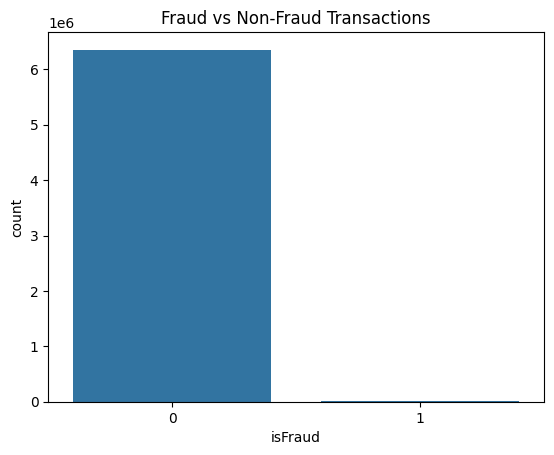

In [17]:
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

**Observation: Fraud Distribution**
* The dataset is highly imbalanced
* Fraudulent transactions account for approximately 0.13% of total transactions
* The vast majority (~99.87%) are legitimate transactions
* This extreme imbalance is typical in fraud detection problems**

**Business Insight**
* Fraud detection is challenging due to the rarity of fraudulent events
* Models trained on such data must focus on identifying rare events without generating excessive false positives

In [18]:
pd.crosstab(df['type'], df['isFraud'])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


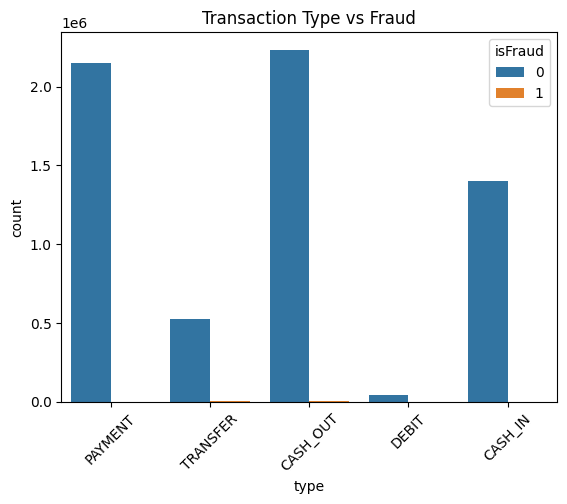

In [19]:
sns.countplot(x='type', hue='isFraud', data=df)
plt.xticks(rotation=45)
plt.title("Transaction Type vs Fraud")
plt.show()

**Observation: Transaction Type vs Fraud**
* Fraudulent transactions are primarily observed in:
  * TRANSFER
  * CASH_OUT
* Other transaction types such as PAYMENT, CASH_IN, and DEBIT show no fraudulent activity

**Business Insight**
* Fraudulent behavior is concentrated in specific transaction types rather than being randomly distributed
* Fraudsters typically use:
  * TRANSFER to move funds between accounts
  * CASH_OUT to withdraw or liquidate funds
* This suggests a common fraud pattern:
  * Transfer → Cash-out → Exit

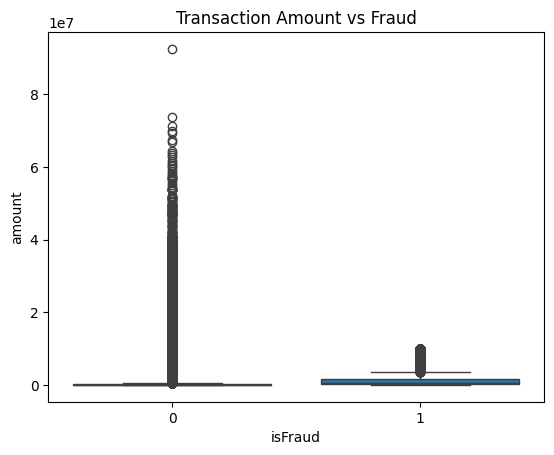

In [20]:
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

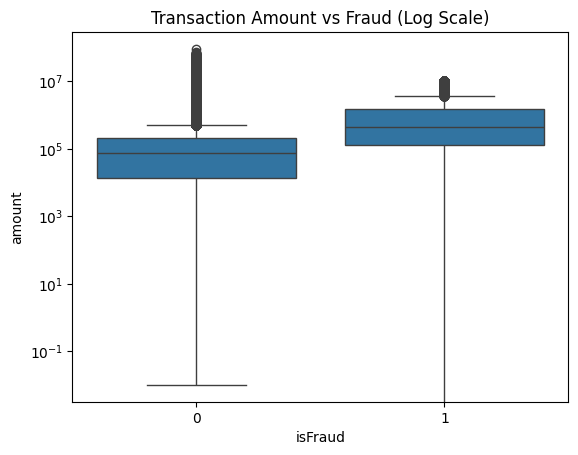

In [21]:
sns.boxplot(x='isFraud', y='amount', data=df)
plt.yscale('log')
plt.title("Transaction Amount vs Fraud (Log Scale)")
plt.show()

In [22]:
df.groupby('isFraud')['amount'].mean()

,amount
isFraud,
0,1.781970e+05
1,1.467967e+06


In [23]:
df.groupby('isFraud')['amount'].median()

,amount
isFraud,
0,74684.72
1,441423.44


**Observation: Transaction Amount vs Fraud**
* Fraudulent transactions have significantly higher transaction amounts compared to non-fraudulent ones
* The median transaction amount for fraud is substantially higher, indicating that this is not driven only by extreme outliers
* This suggests that fraud transactions tend to involve larger monetary values

**Business Insight**
* Fraudsters tend to target high-value transactions to maximize gains
* Larger transaction amounts may indicate higher financial risk
* Transaction amount can serve as an important feature for fraud detection models

In [24]:
df.groupby('isFraud')[['oldbalanceOrg', 'newbalanceOrig']].mean()

,oldbalanceOrg,newbalanceOrig
isFraud,,
0,8.328287e+05,855970.228109
1,1.649668e+06,192392.631836


**Observation: Balance Behavior**
* Fraudulent transactions show a significant drop in sender account balance after the transaction
* The difference between old and new balance is much larger in fraud cases compared to normal transactions
* Non-fraud transactions tend to maintain relatively stable balances

**Business Insight**
* Fraud transactions often involve large withdrawals or transfers, leading to a sharp reduction in account balance
* This behavior indicates potential account draining patterns, where funds are quickly moved out of an account
* Sudden large balance reductions can act as a strong signal for detecting suspicious activity

In [25]:
df.groupby('isFraud')[['oldbalanceDest', 'newbalanceDest']].mean()

,oldbalanceDest,newbalanceDest
isFraud,,
0,1.101421e+06,1.224926e+06
1,5.442496e+05,1.279708e+06


**Observation: Destination Account Behavior**
* Fraudulent transactions show a significant increase in destination account balance
* The increase is much larger compared to non-fraud transactions
* This indicates that large amounts are being transferred to receiving accounts during fraud

**Business Insight**
* Fraudulent activity often involves transferring funds to a destination account quickly
* The destination account experiences a sudden spike in balance, indicating potential suspicious activity
* Monitoring abnormal increases in account balance can help identify fraud patterns

# **Key Fraud Pattern Identified**
* Fraud is concentrated in TRANSFER and CASH_OUT transactions
* Fraudulent transactions involve significantly higher amounts
* Sender account balance shows a sharp decrease
* Destination account balance shows a sudden increase
* This suggests a common fraud pattern:
  * **Funds are transferred and quickly withdrawn, draining the source account**

# **8. Hypothesis Testing**
We statistically evaluate whether transaction amounts differ between fraudulent and non-fraudulent transactions.
* **Null Hypothesis (H₀):** There is no difference in transaction amounts
* **Alternative Hypothesis (H₁):** Fraudulent transactions have different transaction amounts



In [26]:
from scipy.stats import ttest_ind

fraud_amount = df[df['isFraud'] == 1]['amount']
nonfraud_amount = df[df['isFraud'] == 0]['amount']

t_stat, p_value = ttest_ind(fraud_amount, nonfraud_amount, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 48.61450320422929
P-value: 0.0


**Why T-Test is used**
* We are comparing the mean transaction amount between two groups:
  * Fraudulent transactions
  * Non-fraudulent transactions
* Therefore, an independent t-test is appropriate

**Note on Assumptions**
* The data is highly skewed and contains outliers
* While t-test assumes normal distribution, it is still used here for simplicity
* Results should be interpreted cautiously

**Result**
* The p-value is extremely small (approaching zero)

**Conclusion**
* Since p-value < 0.05, we reject the null hypothesis
* There is a statistically significant difference in transaction amounts between fraud and non-fraud transactions

**Insight**
* Transaction amount is a strong distinguishing factor
* Fraudulent transactions tend to involve significantly higher amounts

**Additional Note**
* Due to the large dataset size, even small differences can produce extremely low p-values
* Therefore, practical significance (effect size) should also be considered along with statistical significance

# **9. Feature Engineering**
Feature engineering is performed to create meaningful variables that can improve the performance of fraud detection models.

These features are derived based on transaction behavior, balance changes, and domain knowledge.

In [27]:
df['balance_diff'] = (df['oldbalanceOrg'] - df['amount']) - df['newbalanceOrig']

**Feature: Balance Difference**
* Captures inconsistency in account balance updates
* Helps identify anomalies in transaction behavior

In [28]:
df['amount_to_balance'] = df['amount'] / (df['oldbalanceOrg'] + 1)

**Feature: Amount to Balance Ratio**
* Measures proportion of balance being transferred
* High ratios may indicate suspicious activity

In [29]:
df['is_zero_balance'] = (df['newbalanceOrig'] == 0).astype(int)

**Feature: Zero Balance Indicator**
* Indicates whether the account balance becomes zero after transaction
* Useful for identifying potential account draining behavior

In [30]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

**Feature: Transaction Type Encoding**
* Converts categorical transaction types into numerical features
* Enables model to learn patterns across transaction categories

In [31]:
threshold = df['amount'].quantile(0.95)
df['high_amount'] = (df['amount'] > threshold).astype(int)

**Feature: High Amount Indicator**
* Flags transactions in the top 5% by amount
* Helps capture unusually large transactions

In [32]:
df.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff,amount_to_balance,is_zero_balance,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,high_amount
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0.0,0.057834,0,False,False,True,False,0
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0.0,0.087731,0,False,False,True,False,0
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0.0,0.994505,1,False,False,False,True,0
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,0.0,0.994505,1,True,False,False,False,0
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0.0,0.280788,0,False,False,True,False,0


# **10. Model Building**
In this step, we build a machine learning model to classify fraudulent transactions based on engineered features.

Given the imbalance in the dataset, appropriate evaluation metrics are used.

In [62]:
# Drop unnecessary columns
df_model = df.drop([
    'nameOrig',
    'nameDest',
    'newbalanceOrig',
    'newbalanceDest',
    'balance_diff'
], axis=1)

In [63]:
df_model = df_model.drop(['type_TRANSFER', 'type_CASH_OUT'], axis=1)

In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Sampling ~300K rows from the full dataset (~6.3M rows) for model training
# to reduce computation time while maintaining representative data characteristics

df_model_sample = df_model.sample(300000, random_state=42)
X = df_model_sample.drop('isFraud', axis=1)
y = df_model_sample['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [65]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=50, n_jobs=-1,
                       random_state=42)

In [66]:
y_pred = model.predict(X_test)

In [67]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59922
           1       1.00      0.99      0.99        78

    accuracy                           1.00     60000
   macro avg       1.00      0.99      1.00     60000
weighted avg       1.00      1.00      1.00     60000



In [68]:
y_test.value_counts()
y_test.value_counts(normalize=True)

,proportion
isFraud,
0,0.9987
1,0.0013


In [69]:
y_prob = model.predict_proba(X_test)[:, 1]

# Try stricter threshold
y_pred_05 = (y_prob > 0.5).astype(int)
y_pred_09 = (y_prob > 0.9).astype(int)

from sklearn.metrics import classification_report

print("Threshold 0.5")
print(classification_report(y_test, y_pred_05))

print("\nThreshold 0.9")
print(classification_report(y_test, y_pred_09))

Threshold 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59922
           1       1.00      0.99      0.99        78

    accuracy                           1.00     60000
   macro avg       1.00      0.99      1.00     60000
weighted avg       1.00      1.00      1.00     60000


Threshold 0.9
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59922
           1       1.00      0.81      0.89        78

    accuracy                           1.00     60000
   macro avg       1.00      0.90      0.95     60000
weighted avg       1.00      1.00      1.00     60000



**Threshold Analysis & Trade-off**
* Model predictions were evaluated at different probability thresholds
* Increasing the threshold from 0.5 to 0.9 resulted in:
  * **Decrease in recall** (fewer fraud cases detected)
  * **Precision remained high**, indicating very low false positives


**Key Insight**
* Lower threshold (0.5):
  * Detects more fraud cases
  * Slightly higher risk of false positives
* Higher threshold (0.9):
  * More conservative predictions
  * Misses some fraud but ensures higher confidence

**Business Interpretation**
* In fraud detection systems:
  * **High recall** is important to catch maximum fraud
  * **High precision** is important to avoid blocking legitimate users
* The optimal threshold depends on business priorities:
  * Banking → prioritize recall
  * Customer experience → balance precision

# **Final Insights**
* Fraudulent transactions are highly concentrated in TRANSFER and CASH_OUT types
* Fraud transactions involve significantly higher amounts compared to normal transactions
* Fraud patterns show:
  * Sharp decrease in sender balance
  * Sudden increase in receiver balance
* Transaction amount and balance behavior are strong indicators of fraud

# **Conclusion**
* A machine learning model was built using engineered features and achieved strong performance
* Threshold tuning demonstrated the trade-off between precision and recall
* The dataset shows high separability due to its synthetic nature
* In real-world scenarios, additional complexity and noise would require more robust systems

